In [95]:
"""
I used Chatgpt to assist with explaining code and how to use on python pandas documentation, and to identify methods like dataframe and select_dtypes. All final code, interpretations, and conclusions are my
own work after verification.
"""

'\nI used Chatgpt to assist with explaining code and how to use on python pandas documentation, and to identify methods like dataframe and select_dtypes. All final code, interpretations, and conclusions are my\nown work after verification.\n'

In [96]:
#Task1

import pandas as pd 

#Data Loading and displays first 5 rows of the dataset by default
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [97]:
#Shape, rows and columns
print(df.shape)



(2111, 17)


In [98]:
#Data types of each column
print(df.dtypes)



Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


In [99]:
#Summary statistics of the dataset for numerical columns

df.describe()



,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [100]:
#Check for missing values
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

#Task2

#Missing values table with percentage

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

#DataFrame takes dict of missing value as key and percentage as value to create a table
missing_table = pd.DataFrame({
    "Missing Values": missing_values, 
    "Percentage": missing_percentage
})

print(missing_table)




                                Missing Values  Percentage
Gender                                       0         0.0
Age                                          0         0.0
Height                                       0         0.0
Weight                                       0         0.0
family_history_with_overweight               0         0.0
FAVC                                         0         0.0
FCVC                                         0         0.0
NCP                                          0         0.0
CAEC                                         0         0.0
SMOKE                                        0         0.0
CH2O                                         0         0.0
SCC                                          0         0.0
FAF                                          0         0.0
TUE                                          0         0.0
CALC                                         0         0.0
MTRANS                                       0         0

In [102]:
#Duplicate values check
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")









Number of duplicate rows: 24


In [103]:
#Drop duplicates
df = df.drop_duplicates()
if duplicate_count > 0:
    print("Duplicate rows found:")
    print(df[df.duplicated()])

Duplicate rows found:
Empty DataFrame
Columns: [Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS, NObeyesdad]
Index: []


In [104]:
#detect outliers visual of numerical values


# List of numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Detect outliers using IQR, IQR is a method that identifies outliers by calculating the interquartile range this range specifies the common values in the dataset, and any value that falls outside of this range is considered an outlier. 
outliers = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    #Selects all rows where the value in the column is an outlier, sotes col as key and the outlier rows as value in outleirs dictionary 
    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col} outliers: {len(outliers[col])}")

Age outliers: 167
Height outliers: 1
Weight outliers: 1
FCVC outliers: 0
NCP outliers: 577
CH2O outliers: 0
FAF outliers: 0
TUE outliers: 0


In [105]:
#For each numerical column, calculate IQR then remove values in df where it is outside Q1 and q3
for col in numerical_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Detect outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Remove outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# cleaned dataset
df_cleaned = df




In [106]:
#See if outleirs is actually removed
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns.tolist()


outliers = {}
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    

    outliers[col] = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    
    print(f"{col} outliers: {len(outliers[col])}")

Age outliers: 3
Height outliers: 3
Weight outliers: 0
FCVC outliers: 0
NCP outliers: 255
CH2O outliers: 0
FAF outliers: 0
TUE outliers: 0


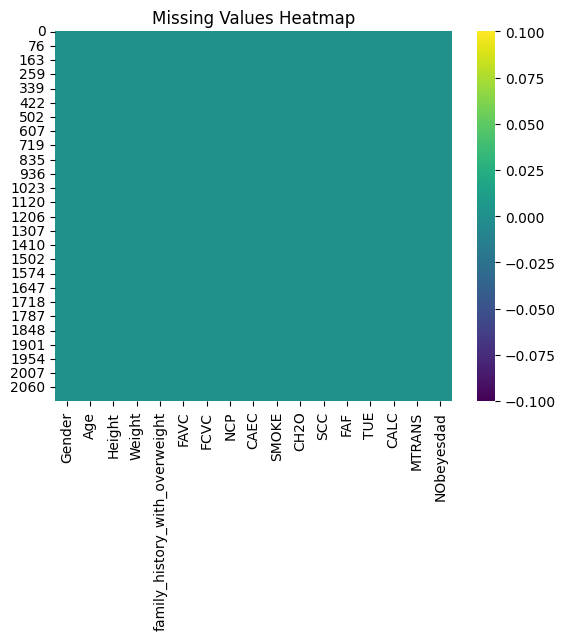

In [107]:

#Missing value heatmap
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

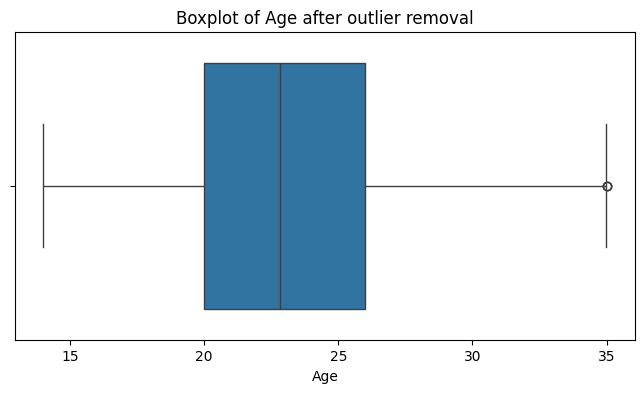

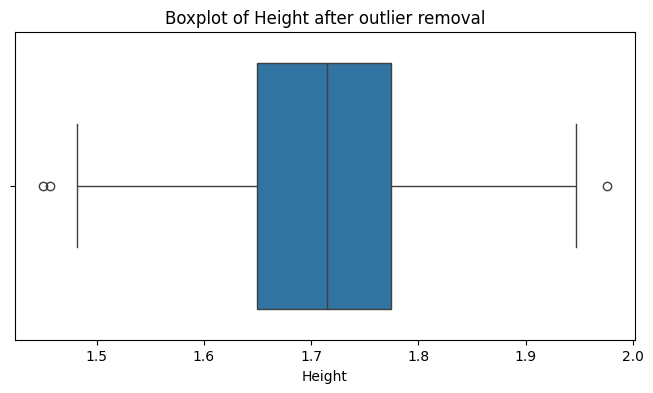

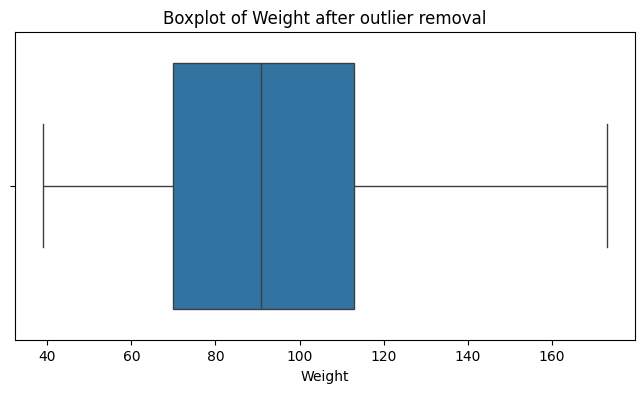

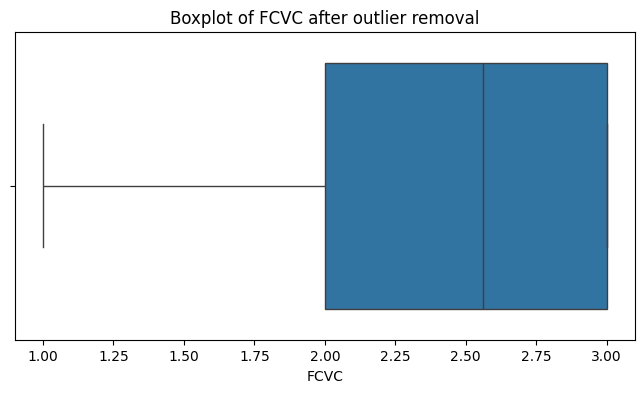

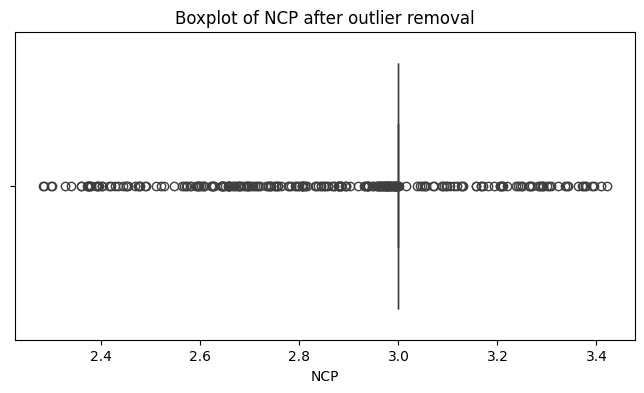

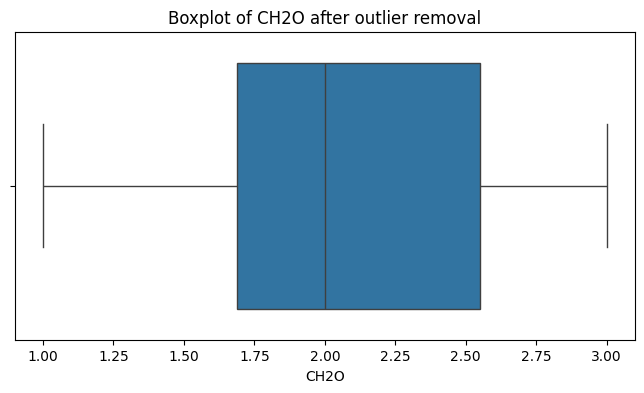

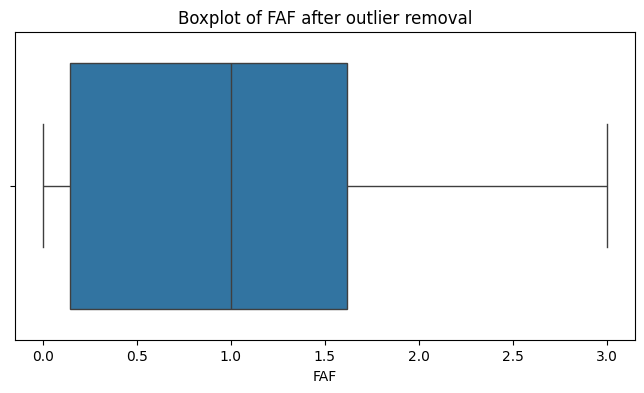

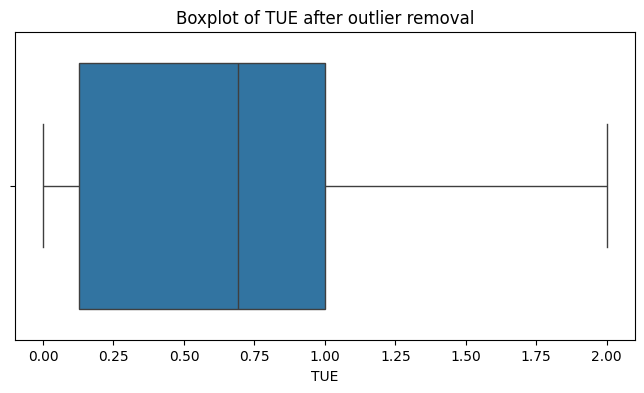

In [108]:
#Boxplot for numerical columns to visually confirm outliers are removed
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Boxplot of {col} after outlier removal")
    plt.show()

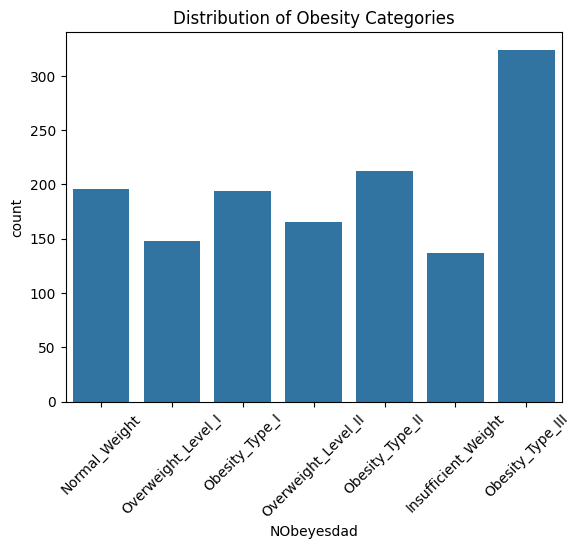

In [109]:
#Task 3 Target variable prepration

#Target variable distribution
sns.countplot(x='NObeyesdad', data=df_cleaned)
plt.xticks(rotation=45)
plt.title("Distribution of Obesity Categories")
plt.show()

In [110]:
#Summary statistics
df_cleaned['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_III       324
Obesity_Type_II        212
Normal_Weight          196
Obesity_Type_I         194
Overweight_Level_II    165
Overweight_Level_I     148
Insufficient_Weight    137
Name: count, dtype: int64

In [111]:
#Task 4: Univariate Analysis

#List of all columns except for NObeyesdad
predictors = df_cleaned.drop(columns=['NObeyesdad']).columns.tolist()

print("Predictor variables:")
print(predictors)

Predictor variables:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


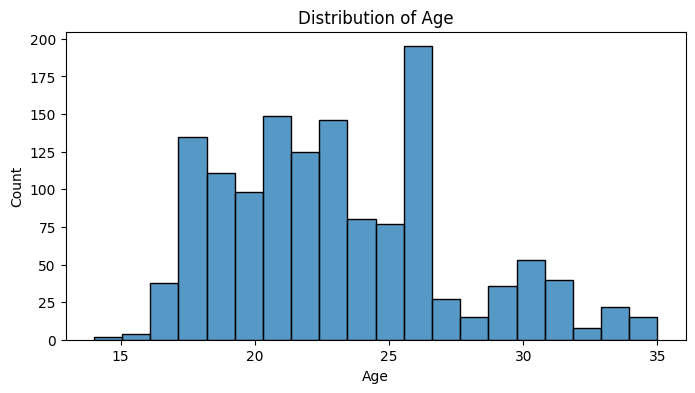

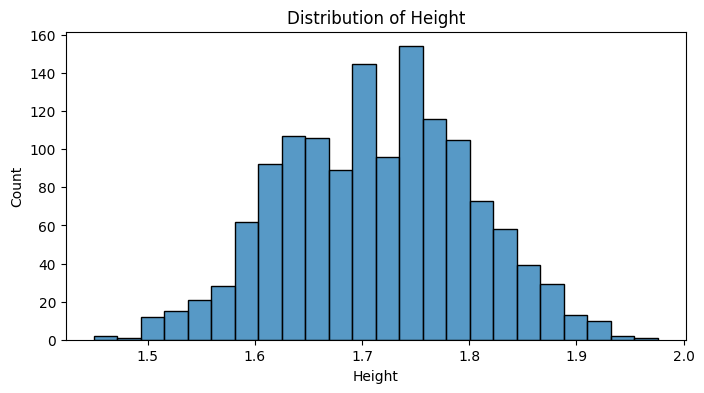

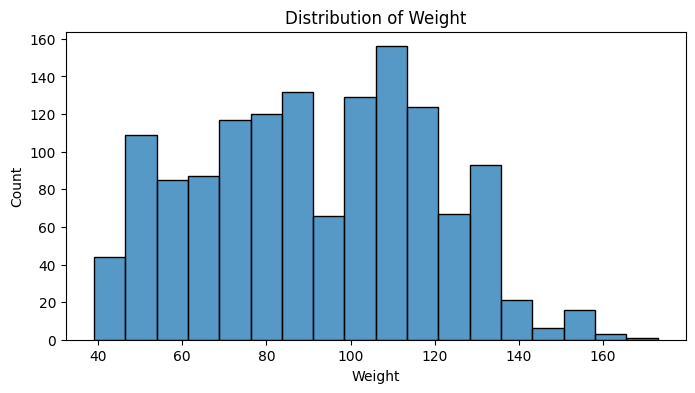

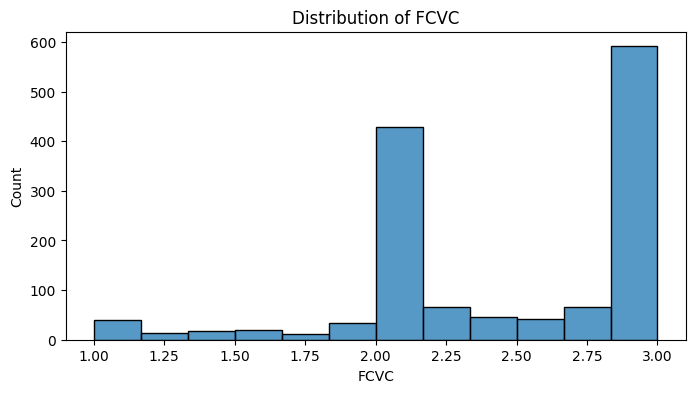

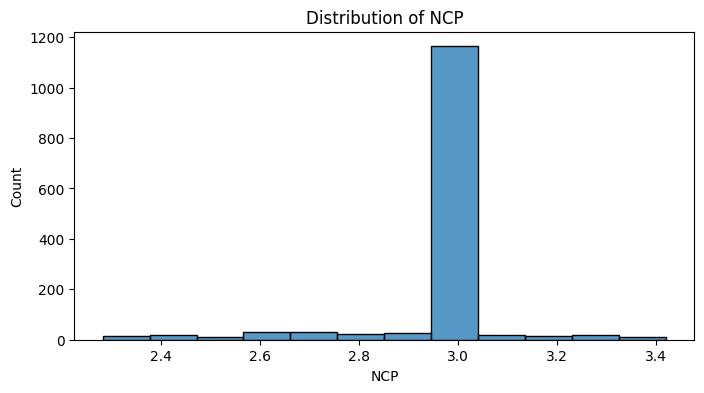

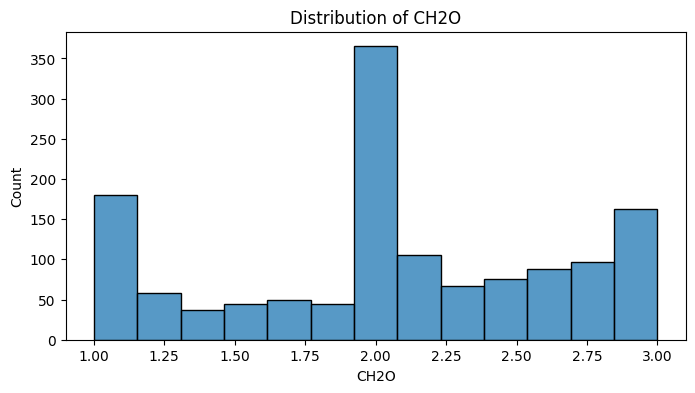

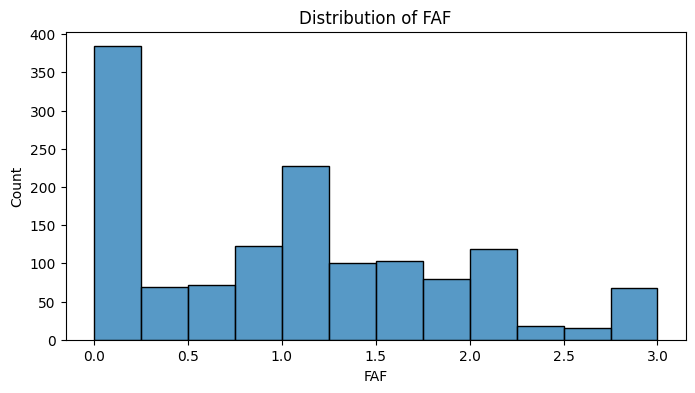

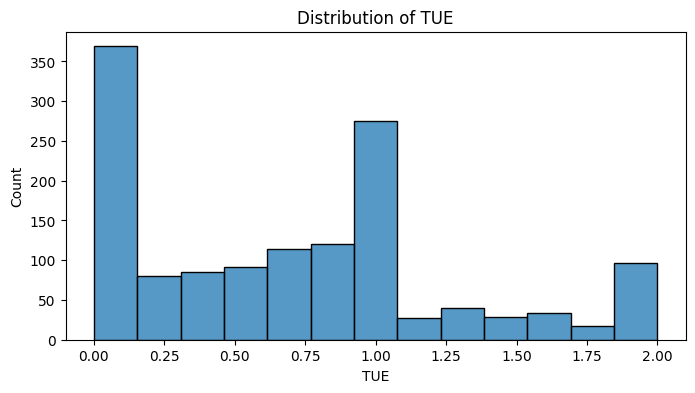

In [112]:
#Distribution plot for numerical predictors at least six
numerical_predictors = df_cleaned.select_dtypes(include=['number']).columns.tolist()

#Loops through each numerical column and plot with data from the column
for col in numerical_predictors:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_cleaned[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [113]:
#Summary statistics for all predictors
summary_stats = df_cleaned.describe()
print(summary_stats)

               Age       Height       Weight         FCVC          NCP  \
count  1376.000000  1376.000000  1376.000000  1376.000000  1376.000000   
mean     23.176560     1.714206    92.136204     2.457434     2.971864   
std       4.165139     0.087318    27.434904     0.548167     0.135518   
min      14.000000     1.450000    39.000000     1.000000     2.282392   
25%      19.988089     1.649789    70.000000     2.000000     3.000000   
50%      22.815036     1.714380    90.834587     2.561869     3.000000   
75%      25.986943     1.774679   112.876378     3.000000     3.000000   
max      35.000000     1.975663   173.000000     3.000000     3.420618   

              CH2O          FAF          TUE  
count  1376.000000  1376.000000  1376.000000  
mean      2.052861     1.027839     0.698627  
std       0.605417     0.849380     0.583422  
min       1.000000     0.000000     0.000000  
25%       1.688207     0.143955     0.126891  
50%       2.000000     1.000000     0.690217  
75% 

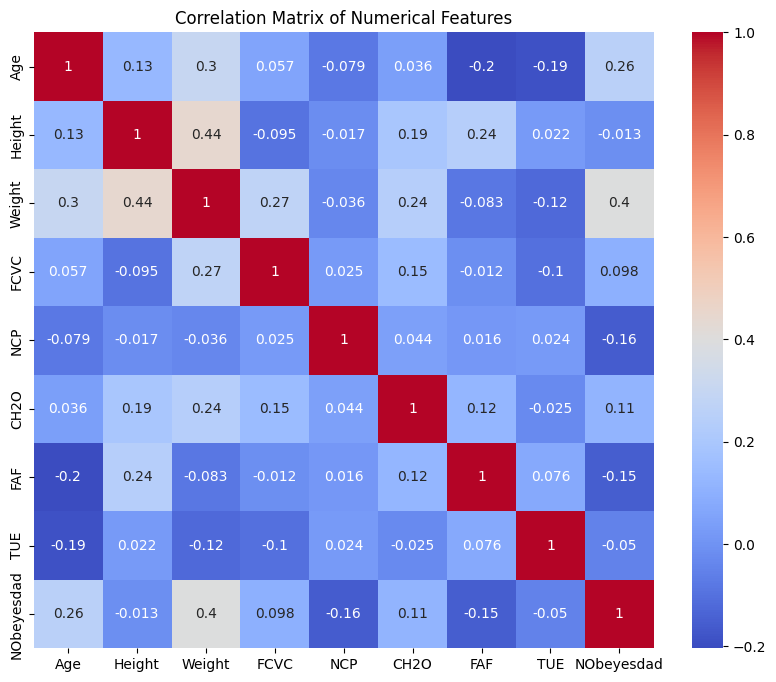

In [114]:
#Task 5: Multivariate Analysis

#Change target variable to numerical for correlation
df_cleaned['NObeyesdad'] = df_cleaned['NObeyesdad'].astype('category').cat.codes

# correlation matrix – use numeric columns only to avoid non-numeric categories
correlation_matrix = df_cleaned.select_dtypes(include=["number"]).corr()

#Visualize the correlation matrix using a heatmap   
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [115]:
#Top 3 correlations with target variable with coeffecient

# Correlation with target variable
target_corr = correlation_matrix['NObeyesdad'].drop('NObeyesdad')

# Get top 3 correlations where the absolute value (turn all numebr to postive) of the correlation is highest
top3 = target_corr.abs().sort_values(ascending=False).head(3)

print("Top 3 features correlated with target:")
print(top3)


Top 3 features correlated with target:
Weight    0.395279
Age       0.257141
NCP       0.157178
Name: NObeyesdad, dtype: float64


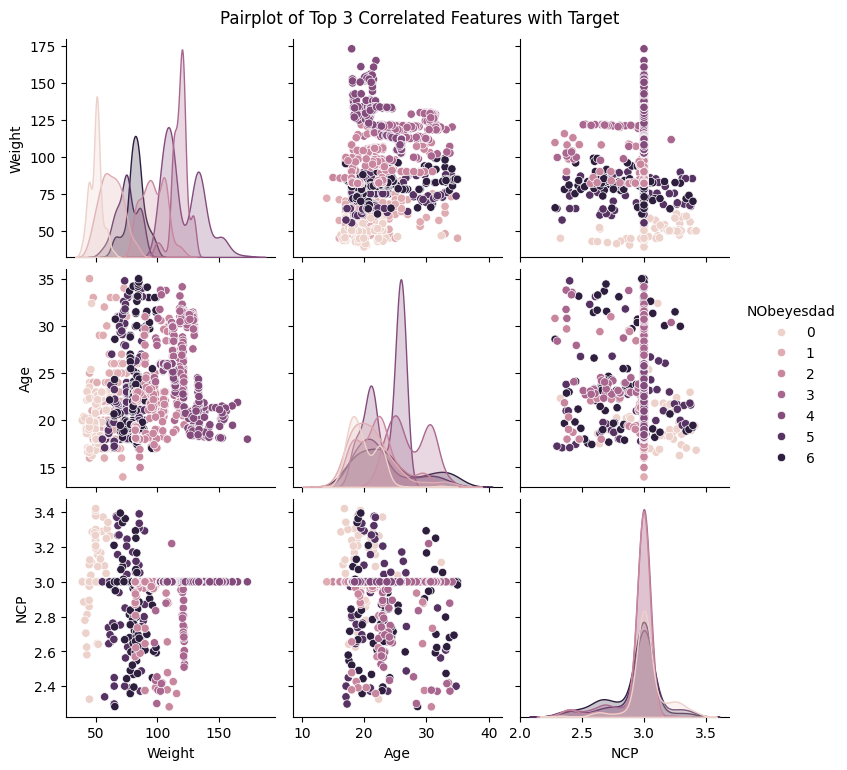

In [116]:
#Pairplot of key feature, use top3 columns inlcuding its index (label) and colors plot with NObeyesdad based on obeseity categories from normal, overweight, obesity type I and etc
sns.pairplot(df_cleaned, vars=top3.index, hue='NObeyesdad')
plt.suptitle("Pairplot of Top 3 Correlated Features with Target", y=1.02)
plt.show()

In [117]:
#Portfolio Assesment 2

In [118]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

#Task1 Target Variable Preperation

#Summary statistics
df_cleaned['NObeyesdad'].value_counts()


NObeyesdad
4    324
3    212
1    196
2    194
6    165
5    148
0    137
Name: count, dtype: int64

In [119]:
#Task 2 Feature Normalisation and Transformation

#2.1 Apply appropriate scaling to all numerical features based on their distribution
df_cleaned.columns = df_cleaned.columns.str.strip()
print('MTRANS' in df_cleaned.columns)  
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
print(numerical_cols)

True
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'NObeyesdad'],
      dtype='object')


In [120]:
#Loops through all numerical column check in range 0 = normal, > 0.5 = Right skewed, < -0.5 = left skewed and > 1 has outleirs
for col in df_cleaned.select_dtypes(include=['number']).columns:
    print(col, "skew:", df[col].skew())

Age skew: 0.6183773216428055
Height skew: -0.03787318325435032
Weight skew: 0.03328222630715835
FCVC skew: -0.5668926546024734
NCP skew: -2.342385810324736
CH2O skew: -0.21877055106178817
FAF skew: 0.4968260693739126
TUE skew: 0.5636491421540043
NObeyesdad skew: -0.08121981388875256


In [121]:
# Columns grouped
standard_cols = ['Height', 'Weight', 'CH2O', 'FAF']
minmax_cols = ['Age', 'FCVC', 'TUE']
robust_cols = ['NCP']

# Apply scaling, Standard scaler Makes data centred, Minmaxscaler shrinks data to 0-1 when there is skewedness and Robustscaler Scales data based on
#Middle values and ignore outliers
df_cleaned[standard_cols] = StandardScaler().fit_transform(df_cleaned[standard_cols])
df_cleaned[minmax_cols] = MinMaxScaler().fit_transform(df_cleaned[minmax_cols])
df_cleaned[robust_cols] = RobustScaler().fit_transform(df_cleaned[robust_cols])

In [122]:
#2.2 Convert all non-numerical features to appropriate numerical representations.

#Find categorical columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='object')


In [123]:
#Check all categories to apply encoding
for col in df_cleaned.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {col}")
    print(df_cleaned[col].value_counts())


Column: Gender
Gender
Male      710
Female    666
Name: count, dtype: int64

Column: family_history_with_overweight
family_history_with_overweight
yes    1170
no      206
Name: count, dtype: int64

Column: FAVC
FAVC
yes    1219
no      157
Name: count, dtype: int64

Column: CAEC
CAEC
Sometimes     1193
Frequently     136
Always          30
no              17
Name: count, dtype: int64

Column: SMOKE
SMOKE
no     1347
yes      29
Name: count, dtype: int64

Column: SCC
SCC
no     1309
yes      67
Name: count, dtype: int64

Column: CALC
CALC
Sometimes     1008
no             325
Frequently      43
Name: count, dtype: int64

Column: MTRANS
MTRANS
Public_Transportation    1123
Automobile                204
Walking                    37
Motorbike                   6
Bike                        6
Name: count, dtype: int64


In [124]:
#Binary encoding for only 2 values

binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].map({
        'yes': 1, 'no': 0,
        'Male': 1, 'Female': 0
    })

In [125]:
#Ordinal encoding For hericachical categories
df_cleaned['CAEC'] = df['CAEC'].map({
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
})

df_cleaned['CALC'] = df['CALC'].map({
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2
})

In [126]:
#Nominal Encoding For no order
df_cleaned = pd.get_dummies(df_cleaned, columns=['MTRANS'])

In [127]:
#Task 4: Decision Tree Modelling & Comparison

#Set1, Original Features
X_set1 = df_cleaned.drop('NObeyesdad', axis=1)  # original features
y = df_cleaned['NObeyesdad']

In [128]:
#Set2,  top 5 features 

corr_target = df_cleaned.corr()['NObeyesdad'].abs().sort_values(ascending=False)
top_features = corr_target[1:6].index  # skip target itself
X_set2 = df_cleaned[top_features]

In [129]:
#Set 3, Original and engineered Features.

# Weight (kg) / (Height in meters)^2
df_cleaned['BMI_ratio'] = df_cleaned['Weight'] / ((df_cleaned['Height']) ** 2)

# FCVC = how often they eat vegetables
# FAF = physical activity frequency
df_cleaned['FCVC_FAF_interaction'] = df_cleaned['FCVC'] * df_cleaned['FAF']

# 3. Unhealthy habits score
df_cleaned['Unhealthy_habits_score'] = (df_cleaned['FAVC'] + df_cleaned['SMOKE'] +  df_cleaned['SCC'] + df_cleaned['CALC'])

# CAEC = extra meals frequency
# TUE = time spent on technology (screen time)
df_cleaned['Meal_frequency_ratio'] = df['CAEC'] / (df['TUE'] + 1) 

engineered_cols = ['BMI_ratio', 'FCVC_FAF_interaction', 'Unhealthy_habits_score', 'Meal_frequency_ratio']
X_set3 = pd.concat([df_cleaned.drop('NObeyesdad', axis=1), df_cleaned[engineered_cols]], axis=1)


In [130]:
#Set 4, Scales features then selects 5 most important features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned.drop('NObeyesdad', axis=1))

pca = PCA(n_components=5)
X_set4 = pca.fit_transform(X_scaled)

In [131]:
#Set 5, Domain selected variables, 
X_set5 = df_cleaned[['BMI_ratio', 'Unhealthy_habits_score', 'FCVC', 'FAF', 'TUE']]

In [132]:
#set 6, Minimal viable set
X_set6 = df_cleaned[['Weight', 'Age', 'NCP']]

In [133]:
from sklearn.model_selection import train_test_split
#Training data sets to put into the model

# Set1
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_set1, y, test_size=0.3, random_state=42)

# Set2
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_set2, y, test_size=0.3, random_state=42)

# Set3
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_set3, y, test_size=0.3, random_state=42)

# Set4
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_set4, y, test_size=0.3, random_state=42)

# Set5
X_train5, X_test5, y_train5, y_test5 = train_test_split(X_set5, y, test_size=0.3, random_state=42)

# Set6
X_train6, X_test6, y_train6, y_test6 = train_test_split(X_set6, y, test_size=0.3, random_state=42)

In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Decision tree, 

#Set1
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X_train1, y_train1)
y_pred1 = dt1.predict(X_test1)


print("Accuracy:", accuracy_score(y_test1, y_pred1))
print(classification_report(y_test1, y_pred1))

#Set2 
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train2, y_train2)
y_pred2 = dt2.predict(X_test2)


print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

#Set2 
dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X_train3, y_train3)
y_pred3 = dt3.predict(X_test3)


print("Accuracy:", accuracy_score(y_test3, y_pred3))
print(classification_report(y_test3, y_pred3))

# Set4
dt4 = DecisionTreeClassifier(random_state=42)
dt4.fit(X_train4, y_train4)
y_pred4 = dt4.predict(X_test4)

print("Accuracy:", accuracy_score(y_test4, y_pred4))
print(classification_report(y_test4, y_pred4))

# Set5
dt5 = DecisionTreeClassifier(random_state=42)
dt5.fit(X_train5, y_train5)
y_pred5 = dt5.predict(X_test5)

print("Accuracy:", accuracy_score(y_test5, y_pred5))
print(classification_report(y_test5, y_pred5))

# Set6
dt6 = DecisionTreeClassifier(random_state=42)
dt6.fit(X_train6, y_train6)
y_pred6 = dt6.predict(X_test6)

print("Accuracy:", accuracy_score(y_test6, y_pred6))
print(classification_report(y_test6, y_pred6))

Accuracy: 0.9128329297820823
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        51
           1       0.73      0.84      0.78        49
           2       0.93      0.93      0.93        57
           3       0.99      1.00      0.99        67
           4       1.00      1.00      1.00        87
           5       0.81      0.80      0.80        44
           6       0.94      0.88      0.91        58

    accuracy                           0.91       413
   macro avg       0.90      0.90      0.90       413
weighted avg       0.92      0.91      0.91       413

Accuracy: 0.8111380145278451
              precision    recall  f1-score   support

           0       0.83      0.75      0.78        51
           1       0.55      0.59      0.57        49
           2       0.75      0.84      0.79        57
           3       0.98      0.93      0.95        67
           4       0.96      0.99      0.97        87
           5       0

In [135]:
#Task 6 Model Improvement


#Shuffle dataset
df_shuffled = df_cleaned.sample(frac=1, random_state=42)

df_shuffled.to_csv('shuffled_data.csv', index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#Train svm

#Features and target
x = df_shuffled[engineered_cols]
#x = df_cleaned.drop('NObeyesdad', axis=1)  # all features except target
#y = df_cleaned['NObeyesdad']
y = df_shuffled['NObeyesdad']


#Train adn testing split, 70:30
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state=42
)

# Preserve for GridSearchCV later
x_test_grid = x_test.copy()
y_test_grid = y_test.copy()

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Train SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)

#Predict
y_pred = svm_model.predict(x_test)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8329297820823245


In [53]:
# 5 fold Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])


#5-Fold CV
cv_score = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')

print(f"Cross vali score {cv_score}")
print(cv_score.mean())

Cross vali score [0.48913043 0.52       0.51636364 0.45454545 0.53454545]
0.5029169960474309


In [54]:
#Task 7     
from sklearn.model_selection import GridSearchCV

#Define Hyper Parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

#GridSearchCV setup
grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=3, scoring='accuracy')

#Fit on the scaled engineered features
grid.fit(x_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.487 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.456 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.492 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.490 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.474 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.337 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.415 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.373 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.380 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.380 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.337 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=3)

In [55]:
print("Best Hyperparameters:", grid.best_params_)
print("Best Estimator:", grid.best_estimator_)

Best Hyperparameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best Estimator: SVC(C=10, gamma=1)


In [58]:
grid_predictions = grid.predict(x_test)

print(classification_report(y_test_grid, grid_predictions))

print(df_shuffled.shape)

              precision    recall  f1-score   support

           0       0.50      0.41      0.45        49
           1       0.32      0.28      0.30        64
           2       0.40      0.28      0.33        50
           3       0.41      0.69      0.52        68
           4       0.73      0.91      0.81        88
           5       0.40      0.20      0.27        49
           6       0.45      0.33      0.38        45

    accuracy                           0.49       413
   macro avg       0.46      0.44      0.44       413
weighted avg       0.48      0.49      0.47       413

(1376, 25)


In [61]:
#Optimized SVM
optimized_svm = SVC(C=10, gamma=1, kernel='rbf', random_state=42)
optimized_svm.fit(x_train, y_train)

y_pred = optimized_svm.predict(x_test)

accuracy_split = accuracy_score(y_test, y_pred)

print(f'svm acc {accuracy_split}')
print(f"Classification Report: {classification_report(y_test, y_pred)}")

#5fold
cv_scores = cross_val_score(optimized_svm, scaler.transform(x), y, cv=5, scoring='accuracy')
print(f'cv_scores {cv_scores}')
print(f'Average score{cv_scores.mean()}')

svm acc 0.4939467312348668
Classification Report:               precision    recall  f1-score   support

           0       0.50      0.41      0.45        49
           1       0.32      0.28      0.30        64
           2       0.40      0.28      0.33        50
           3       0.41      0.69      0.52        68
           4       0.73      0.91      0.81        88
           5       0.40      0.20      0.27        49
           6       0.45      0.33      0.38        45

    accuracy                           0.49       413
   macro avg       0.46      0.44      0.44       413
weighted avg       0.48      0.49      0.47       413

cv_scores [0.53623188 0.52       0.55272727 0.45090909 0.51272727]
Average score0.5145191040843216


In [80]:
#Task 8 Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

#Selects top 5 featuers 
selector = SelectKBest(score_func=f_classif, k=2)
x_new = selector.fit_transform(x, y)

#Get selected feature names
selected_features = x.columns[selector.get_support()]
print(f'selected featuer {selected_features}')

selected featuer Index(['Unhealthy_habits_score', 'Meal_frequency_ratio'], dtype='object')


In [81]:
#Train and split on new features
x_train, x_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [82]:
#Optimized SVM with new feautres
# Optimized SVM with hyperparameters from Task 7
optimized_svm = SVC(C=10, gamma=1, kernel='rbf', random_state=42)
optimized_svm.fit(x_train_scaled, y_train)

# Predict on test set
y_pred = optimized_svm.predict(x_test_scaled)

# 70:30 Split Accuracy
accuracy_split = accuracy_score(y_test, y_pred)
print("SVM Accuracy", accuracy_split)
print("Classification", classification_report(y_test, y_pred))

cv_scores = cross_val_score(optimized_svm, scaler.transform(x_new), y, cv=5, scoring='accuracy')
print("CV Accuracy Scores:", cv_scores)
print("5Fold  avg Accuracy:", cv_scores.mean())

print(df_shuffled.shape)

SVM Accuracy 0.43099273607748184
Classification               precision    recall  f1-score   support

           0       0.56      0.24      0.34        41
           1       0.40      0.37      0.39        59
           2       0.31      0.28      0.29        58
           3       0.33      0.47      0.38        64
           4       0.50      0.91      0.64        97
           5       0.54      0.16      0.25        44
           6       0.71      0.10      0.18        50

    accuracy                           0.43       413
   macro avg       0.48      0.36      0.35       413
weighted avg       0.47      0.43      0.39       413

CV Accuracy Scores: [0.44565217 0.46181818 0.46545455 0.38545455 0.45454545]
5Fold  avg Accuracy: 0.4425849802371541
(1376, 25)


In [83]:
#Dimensionality Reduction with PCA

#Standardized featuers for x scaled
x_scaled = scaler.fit_transform(x)
print("Shape before PCA:", x_scaled.shape)

#Apply pca with top 4 components (max is 4 since x has only 4 features)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print("Shape after PCA:", x_pca.shape)

Shape before PCA: (1376, 4)
Shape after PCA: (1376, 2)


In [84]:
#Train and test
x_train, x_test, y_train, y_test = train_test_split(
    x_pca, y, test_size=0.3, random_state=42, stratify=y
)



In [85]:
optimized_svm = SVC(C=10, gamma=1, kernel='rbf', random_state=42)
optimized_svm.fit(x_train, y_train)

# Predict on test set
y_pred = optimized_svm.predict(x_test)

# 70:30 Split Accuracy
accuracy_split = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", accuracy_split)
print("Classification Report", classification_report(y_test, y_pred))

#5fold
cv_scores = cross_val_score(optimized_svm, x_pca, y, cv=5, scoring='accuracy')
print("5Fold acc", cv_scores)
print("Average 5FoldAccuracy:", cv_scores.mean())

SVM Accuracy: 0.46246973365617433
Classification Report               precision    recall  f1-score   support

           0       0.50      0.37      0.42        41
           1       0.48      0.22      0.30        59
           2       0.28      0.31      0.29        58
           3       0.34      0.78      0.47        64
           4       0.71      0.90      0.79        97
           5       0.60      0.07      0.12        44
           6       0.33      0.10      0.15        50

    accuracy                           0.46       413
   macro avg       0.46      0.39      0.37       413
weighted avg       0.48      0.46      0.42       413

5Fold acc [0.4673913  0.48       0.49090909 0.4        0.46545455]
Average 5FoldAccuracy: 0.46075098814229254


Accuracy: 0.4552058111380145
